#### This Line is for Github reference. This file's initial commit will be here

##### Tasks Which we are going to perform in our project
###### 1.) Data Preprocessing (cleaning)
###### 2.) Relax Assumptions
###### 3.) Log Transformation
###### 4.) Create a Model
###### 5.) Create Dummies

#### Importing Relevant Libraries

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
sns.set()

#### loading the Raw Data

In [2]:
raw_data = pd.read_csv('Real_life_example.csv')
raw_data.head()

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4


## **Preprocessing**

#### **Descriptive Statistics of the Variables**

In [3]:
raw_data.describe(include = 'all')                       #else you will get statistics of numerical variables only

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000,4345
unique,7,NaN,6,NaN,NaN,4,2,NaN,312
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN,199
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058,NaN
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000,NaN
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000,NaN


###### Now we have descriptives for categorical variables, too
###### (count) for each variables are not same (diff no. of observations) there are some missing values
###### unique entries for categorical variables, there are 312 unique models (very hard to implement in regression) With our current knowledge that would mean more than 300 dummies
###### Volkswagen is most common car sold with frequency of 936.
###### A lot of the information from 'Model' could be engineered from 'Brand' 'Year' and 'EngineV', so we won't be losing too much variability


#### **Determining Variables of interest**

In [4]:
data = raw_data.drop(['Model'], axis =1)
data.describe(include ='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000


###### as you can see total entries (row) = 4345 but Price and EngineV column have missing values

#### **Dealing With missing Values**

In [5]:
data.isnull()

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
4340,False,False,False,False,False,False,False,False
4341,False,False,False,False,False,False,False,False
4342,False,False,False,False,False,False,False,False
4343,False,False,False,False,True,False,False,False


In [6]:
data.isnull().sum()

Brand             0
Price           172
Body              0
Mileage           0
EngineV         150
Engine Type       0
Registration      0
Year              0
dtype: int64

##### **Rule: if you are removing <5% of the observations, you are free to just remove all that have missing values**

In [7]:
data_no_mv = data.dropna(axis = 0)
data_no_mv.describe(include = 'all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,4025,4025.000000,4025,4025.000000,4025.000000,4025,4025,4025.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,880,NaN,1534,NaN,NaN,1861,3654,NaN
mean,NaN,19552.308065,NaN,163.572174,2.764586,NaN,NaN,2006.379627
std,NaN,25815.734988,NaN,103.394703,4.935941,NaN,NaN,6.695595
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6999.000000,NaN,90.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11500.000000,NaN,158.000000,2.200000,NaN,NaN,2007.000000
75%,NaN,21900.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000


#### **Exploring Probability Distribution functions PDFs**

<Axes: xlabel='Price', ylabel='Count'>

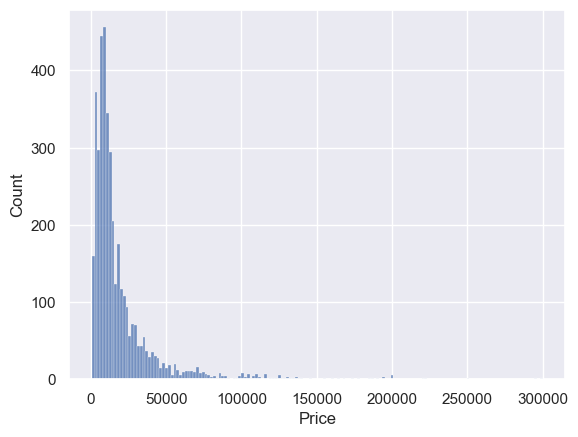

In [8]:
sns.histplot(data_no_mv['Price'])

###### As we can observe we have few outliers in 'Price' variable
###### **Outliers** : observations that lie on abnormal distance from other observations in the data
###### Simplest way to deal with outliers seemlessly is to remove top 1% of the observations

#### **Dealing with Outliers**

In [ ]:
# Obviously there are some outliers present 

# Without diving too deep into the topic, we can deal with the problem easily by removing 0.5%, or 1% of the problematic samples
# Here, the outliers are situated around the higher prices (right side of the graph)
# Logic should also be applied
# This is a dataset about used cars, therefore one can imagine how $300,000 is an excessive price

# Outliers are a great issue for OLS, thus we must deal with them in some way
# It may be a useful exercise to try training a model without removing the outliers

# Let's declare a variable that will be equal to the 99th percentile of the 'Price' variable
q = data_no_mv['Price'].quantile(0.99)
# Then we can create a new df, with the condition that all prices must be below the 99 percentile of 'Price'
data_1 = data_no_mv[data_no_mv['Price']<q]
# In this way we have essentially removed the top 1% of the data about 'Price'
data_1.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,3984,3984.000000,3984,3984.000000,3984.000000,3984,3984,3984.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,880,NaN,1528,NaN,NaN,1853,3613,NaN
mean,NaN,17837.117460,NaN,165.116466,2.743770,NaN,NaN,2006.292922
std,NaN,18976.268315,NaN,102.766126,4.956057,NaN,NaN,6.672745
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6980.000000,NaN,93.000000,1.800000,NaN,NaN,2002.750000
50%,NaN,11400.000000,NaN,160.000000,2.200000,NaN,NaN,2007.000000
75%,NaN,21000.000000,NaN,230.000000,3.000000,NaN,NaN,2011.000000


In [ ]:
sns.distplot(data_1['Price'])

###### **Checking other variables as well**

In [ ]:
sns.distplot(data_no_mv['Mileage'])

In [ ]:
# Dealing the same way as earlier

q = data_1['Mileage'].quantile(0.99)
data_2 = data_1[data_1['Mileage']<q]

In [ ]:
sns.distplot(data_2['Mileage'])

In [ ]:
sns.distplot(data_no_mv['EngineV'])

###### **Engine volume should fall between 0.6 to 6.5**

In [ ]:
data_3 = data_2[data_2['EngineV']<6.5]

In [ ]:
sns.distplot(data_3['EngineV'])

In [ ]:
sns.distplot(data_no_mv['Year'])

In [ ]:
q = data_3['Year'].quantile(0.01)
data_4 = data_3[data_3['Year']>q]

In [ ]:
sns.distplot(data_4['Year'])

### **Cleaned DATA**

In [ ]:
data_cleaned = data_4.reset_index(drop = True)

In [ ]:
data_cleaned.describe(include = 'all')

## **Checking OLS Assumptions**

### **1.) Linearity Assumptions**

In [ ]:
f, (ax1, ax2, ax3) = plt.subplots(1,3, sharey = True, figsize = (15,3))
ax1.scatter(data_cleaned['Year'], data_cleaned['Price'])
ax1.set_title('Price and Year')
ax2.scatter(data_cleaned['EngineV'], data_cleaned['Price'])
ax2.set_title('Price and EngineV')
ax3.scatter(data_cleaned['Mileage'], data_cleaned['Price'])
ax3.set_title('Price and Mileage')
plt.show()

###### We can see the relationships are not linear in any of the plot
##### **We should first transform one or more variables**
##### **log Transformations**

In [ ]:
sns.distplot(data_cleaned['Price'])

In [ ]:
log_price = np.log(data_cleaned['Price'])
data_cleaned['log_price'] = log_price
data_cleaned

In [ ]:
f, (ax1, ax2, ax3) = plt.subplots(1,3, sharey = True, figsize = (15,3))
ax1.scatter(data_cleaned['Year'], data_cleaned['log_price'])
ax1.set_title('Log Price and Year')
ax2.scatter(data_cleaned['EngineV'], data_cleaned['log_price'])
ax2.set_title('Log Price and EngineV')
ax3.scatter(data_cleaned['Mileage'], data_cleaned['log_price'])
ax3.set_title('Log Price and Mileage')
plt.show()

In [ ]:
#now original price is no longer needed as log_price working fine for linearization
data_cleaned = data_cleaned.drop(['Price'], axis =1)
data_cleaned

### **2.) No Endogeneity Assumption**

##### I believe that all the relevent variables are taken without mistake. May discuss later after regression

### **3.) Normality & homoscadasticity**

###### **Normality:** We assume error term is normally distributed
###### **Zero mean of error term:** if the mean is not aspected to be zero then the line is not best fitting line
###### **Homoscadasticity:** error from the mean is equivalently distributed (already valid true because we have already taken log_transformation which is most common fix for heteroscadasticity

### **4.) No Auto Correlation**

###### Error should be randomly distributed across the regression line
######         i) plot on graph and look for patterns if no patterns to be seen ==> no autocorrelation
######         ii) Durbin-Watson Test
######                    Durbin-Watson: 0.950
######                                   if 2 -----> not autocorrelation
######                                   if <1 and >3 cause an alarm
###### **Random car sales data we have taken therefore we are safe to go**

### **5.) Multicollinearity**

###### it is logical that 'year' and 'mileage' will be corelated
###### sklearn doesn't have dedicated method to check this assumption (**Statsmodels will help now**)
###### **One of the best ways to check for multicollinearity is through VIF (variance inflation factor)**

In [ ]:
# Use this as ready-made code
from statsmodels.stats.outliers_influence import variance_inflation_factor
variables = data_cleaned[['Mileage','Year','EngineV']]
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(variables.values,i) for i in range (variables.shape[1])]
vif["features"] = variables.columns

In [ ]:
vif

###### vif = (0, +infinity)
###### if vif = 1 no multicollinearity
###### if 1<vif<5 perfectly okay
###### if vif>10 unacceptable

In [ ]:
data_no_multicollinearity = data_cleaned.drop(['Year'],axis=1)

## **Create Dummy Variables**

In [ ]:
# To include the categorical data in the regression, let's create dummies
# There is a very convenient method called: 'get_dummies' which does that seemlessly
# It is extremely important that we drop one of the dummies, alternatively we will introduce multicollinearity

data_with_dummies = pd.get_dummies(data_no_multicollinearity, drop_first = True)

In [ ]:
data_with_dummies.head()

In [ ]:
data_with_dummies.columns.values

In [ ]:
# To make the code a bit more parametrized, let's declare a new variable that will contain the preferred order
# If you want a different order, just specify it here
# Conventionally, the most intuitive order is: dependent variable, indepedendent numerical variables, dummies

cols = ['log_price','Mileage', 'EngineV', 'Brand_BMW',
       'Brand_Mercedes-Benz', 'Brand_Mitsubishi', 'Brand_Renault',
       'Brand_Toyota', 'Brand_Volkswagen', 'Body_hatch', 'Body_other',
       'Body_sedan', 'Body_vagon', 'Body_van', 'Engine Type_Gas',
       'Engine Type_Other', 'Engine Type_Petrol', 'Registration_yes']

In [ ]:
data_preprocessed = data_with_dummies[cols]
data_preprocessed.head()

# **Linear Regression Model**

#### **Declare inputs and targets**

In [ ]:
targets = data_preprocessed['log_price']
inputs = data_preprocessed.drop(['log_price'], axis = 1)

#### **Scale the data**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(inputs)

In [ ]:
input_scaled = scaler.transform(inputs)

#### **Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(input_scaled, targets, test_size = 0.2, random_state=365)

#### **Create the Regression**

In [ ]:
reg = LinearRegression()
reg.fit(x_train, y_train)

In [ ]:
# Let's check the outputs of the regression
# I'll store them in y_hat as this is the 'theoretical' name of the predictions

y_hat = reg.predict(x_train)

In [ ]:
# The simplest way to compare the targets (y_train) and the predictions (y_hat) is to plot them on a scatter plot
# The closer the points to the 45-degree line, the better the prediction
plt.scatter(y_train, y_hat)
# Let's also name the axes
plt.xlabel('Targets (y_train)',size=18)
plt.ylabel('Predictions (y_hat)',size=18)
# Sometimes the plot will have different scales of the x-axis and the y-axis
# This is an issue as we won't be able to interpret the '45-degree line'
# We want the x-axis and the y-axis to be the same
plt.xlim(6,13)
plt.ylim(6,13)
plt.show()

In [ ]:
# Another useful check of our model is a residual plot
# We can plot the PDF of the residuals and check for anomalies
sns.distplot(y_train - y_hat)

# Include a title
plt.title("Residuals PDF", size=18)

# In the best case scenario this plot should be normally distributed
# In our case we notice that there are many negative residuals (far away from the mean)
# Given the definition of the residuals (y_train - y_hat), negative values imply
# that y_hat (predictions) are much higher than y_train (the targets)
# This is food for thought to improve our model

In [ ]:
# Find the R-squared of the model
reg.score(x_train,y_train)

# Note that this is NOT the adjusted R-squared
# in other words... find the Adjusted R-squared to have the appropriate measure :)

#### **Finding the weights and bias**

In [ ]:
# Obtain the bias (intercept) of the regression
reg.intercept_

In [ ]:
# Obtain the weights (coefficients) of the regression
reg.coef_

# Note that they are barely interpretable if at all

In [ ]:
# Create a regression summary where we can compare them with one-another
reg_summary = pd.DataFrame(inputs.columns.values, columns=['Features'])
reg_summary['Weights'] = reg.coef_
reg_summary

In [ ]:
# Check the different categories in the 'Brand' variable
data_cleaned['Brand'].unique()

# In this way we can see which 'Brand' is actually the benchmark
# here 'Audi' is the benchmark (see dummy variables)